In [9]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

In [10]:
df = pd.read_csv('retail_sales_dataset.csv')

In [102]:
# Check missing values
df.isnull().sum()

# Check duplicates
df.duplicated().sum()

# Remove duplicates if any
df.drop_duplicates(inplace=True)

# Verify datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   index             1000 non-null   int64         
 1   Transaction ID    1000 non-null   int64         
 2   Date              1000 non-null   datetime64[ns]
 3   Customer ID       1000 non-null   object        
 4   Gender            1000 non-null   object        
 5   Age               1000 non-null   int64         
 6   Product Category  1000 non-null   object        
 7   Quantity          1000 non-null   int64         
 8   Price per Unit    1000 non-null   int64         
 9   Total Amount      1000 non-null   int64         
 10  month             1000 non-null   int32         
 11  season            1000 non-null   object        
 12  Holiday           1000 non-null   int64         
dtypes: datetime64[ns](1), int32(1), int64(7), object(4)
memory usage: 97.8+ KB


#  exploring Data Analysis 

In [12]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [13]:
df.sample()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
50,51,2023-10-02,CUST051,Male,27,Beauty,3,25,75


In [14]:
df.shape

(1000, 9)

In [15]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [16]:
df.columns.to_list()

['Transaction ID',
 'Date',
 'Customer ID',
 'Gender',
 'Age',
 'Product Category',
 'Quantity',
 'Price per Unit',
 'Total Amount']

In [17]:
for col in df.columns: 
    print(col)
    print(df[col].unique())
    print('=' * 50)

Transaction ID
[   1    2    3    4    5    6    7    8    9   10   11   12   13   14
   15   16   17   18   19   20   21   22   23   24   25   26   27   28
   29   30   31   32   33   34   35   36   37   38   39   40   41   42
   43   44   45   46   47   48   49   50   51   52   53   54   55   56
   57   58   59   60   61   62   63   64   65   66   67   68   69   70
   71   72   73   74   75   76   77   78   79   80   81   82   83   84
   85   86   87   88   89   90   91   92   93   94   95   96   97   98
   99  100  101  102  103  104  105  106  107  108  109  110  111  112
  113  114  115  116  117  118  119  120  121  122  123  124  125  126
  127  128  129  130  131  132  133  134  135  136  137  138  139  140
  141  142  143  144  145  146  147  148  149  150  151  152  153  154
  155  156  157  158  159  160  161  162  163  164  165  166  167  168
  169  170  171  172  173  174  175  176  177  178  179  180  181  182
  183  184  185  186  187  188  189  190  191  192  193  194  

In [18]:
df['Date'].sort_values(ascending=True)

521   2023-01-01
179   2023-01-01
558   2023-01-01
302   2023-01-02
978   2023-01-02
         ...    
232   2023-12-29
804   2023-12-29
856   2023-12-31
210   2024-01-01
649   2024-01-01
Name: Date, Length: 1000, dtype: datetime64[ns]

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [20]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [21]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [22]:
df.isna().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [23]:
df.corr(numeric_only=True)

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
Transaction ID,1.000000,0.065191,-0.026623,-0.060837,-0.075034
Age,0.065191,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.026623,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.060837,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.075034,-0.060568,0.373707,0.851925,1.000000


# Date 

In [24]:
df['Date'] = pd.to_datetime(df['Date'])

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [26]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [27]:
df['Date'].head()

0   2023-11-24
1   2023-02-27
2   2023-01-13
3   2023-05-21
4   2023-05-06
Name: Date, dtype: datetime64[ns]

In [28]:
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [29]:
df = df.reset_index()

In [30]:
df['month'] = df['Date'].dt.month

In [31]:
df

,index,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,month
0,0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11
1,1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2
2,2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1
3,3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5
4,4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5
...,...,...,...,...,...,...,...,...,...,...,...
995,995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,5
996,996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,11
997,997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,10
998,998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,12


In [32]:
df_cust = df.groupby(['month'],as_index=False)['Customer ID'].count().sort_values(by='Customer ID',ascending=False)
df_cust

,month,Customer ID
4,5,105
9,10,96
7,8,94
11,12,91
3,4,86
1,2,85
0,1,78
10,11,78
5,6,77
2,3,73


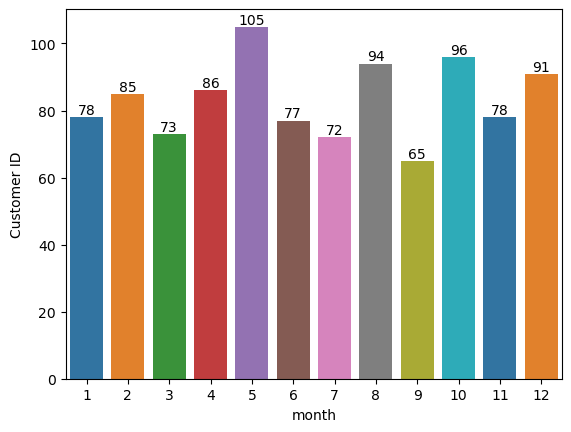

In [33]:
ax = sns.barplot(x='month',y='Customer ID',data=df_cust,palette=sns.color_palette("tab10"))
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

In [34]:
df_Gender = df.groupby(['month'],as_index=False)['Gender'].value_counts()
df_Gender

,month,Gender,count
0,1,Female,40
1,1,Male,38
2,2,Male,49
3,2,Female,36
4,3,Female,41
5,3,Male,32
6,4,Female,50
7,4,Male,36
8,5,Male,60
9,5,Female,45


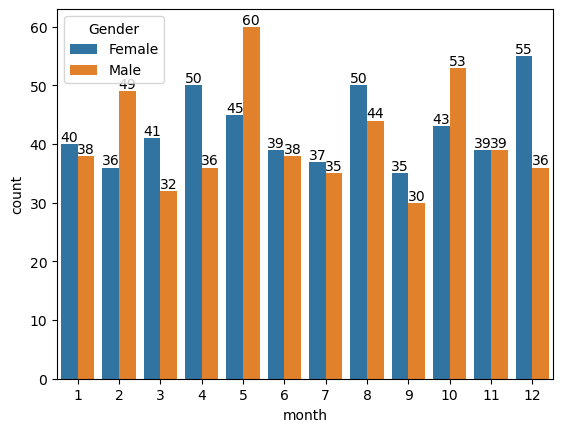

In [35]:
ax = sns.barplot(x='month', y='count', hue='Gender', data=df_Gender, palette=sns.color_palette("tab10"))

for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

In [36]:
df

,index,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,month
0,0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11
1,1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2
2,2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1
3,3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5
4,4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5
...,...,...,...,...,...,...,...,...,...,...,...
995,995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,5
996,996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,11
997,997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,10
998,998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,12


In [37]:
df_Quantity = df.groupby(['month'],as_index=False)['Quantity'].sum()
df_Quantity

,month,Quantity
0,1,199
1,2,214
2,3,194
3,4,214
4,5,259
5,6,197
6,7,176
7,8,227
8,9,170
9,10,252


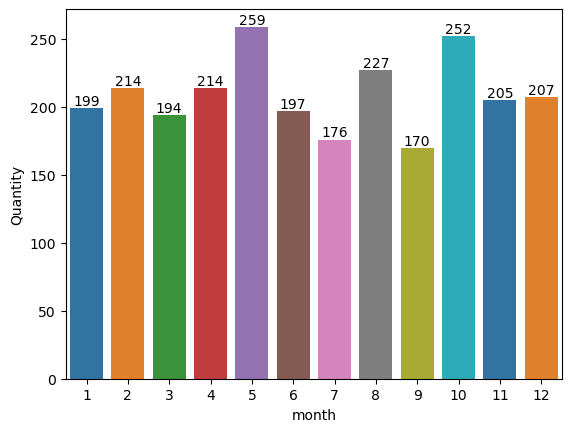

In [38]:
ax = sns.barplot(x='month',y='Quantity',data=df_Quantity,palette=sns.color_palette("tab10"))
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

In [39]:
df

,index,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,month
0,0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11
1,1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2
2,2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1
3,3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5
4,4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5
...,...,...,...,...,...,...,...,...,...,...,...
995,995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,5
996,996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,11
997,997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,10
998,998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,12


In [40]:
df_Total= df.groupby(['month'],as_index=False)['Total Amount'].sum()
df_Total

,month,Total Amount
0,1,36980
1,2,44060
2,3,28990
3,4,33870
4,5,53150
5,6,36715
6,7,35465
7,8,36960
8,9,23620
9,10,46580


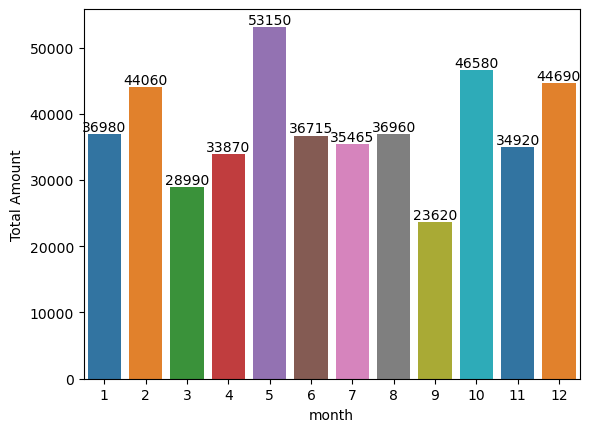

In [41]:
ax = sns.barplot(x='month',y='Total Amount',data=df_Total,palette=sns.color_palette("tab10"))
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

In [42]:
df

,index,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,month
0,0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11
1,1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2
2,2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1
3,3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5
4,4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5
...,...,...,...,...,...,...,...,...,...,...,...
995,995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,5
996,996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,11
997,997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,10
998,998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,12


# Customer ID

In [43]:
df['Customer ID'].value_counts().count()

np.int64(1000)

In [44]:
df['Customer ID'].describe()

count        1000
unique       1000
top       CUST001
freq            1
Name: Customer ID, dtype: object

# Gender

In [45]:
df_Gend = df['Gender'].value_counts(normalize=True) * 100
df_Gend

Gender
Female    51.0
Male      49.0
Name: proportion, dtype: float64

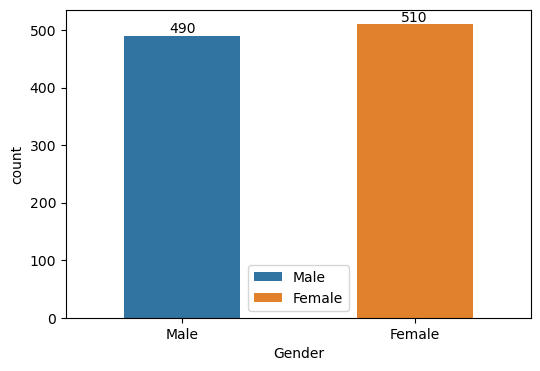

In [46]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x=df['Gender'],data=df,palette=sns.color_palette("tab10"),width=.5)
plt.legend(['Male','Female'])
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

In [47]:
df.groupby(['Gender'])['Age'].mean()

Gender
Female    41.356863
Male      41.428571
Name: Age, dtype: float64

In [48]:
df_q = df.groupby(['Gender'],as_index=False)['Quantity'].sum()
df_q 

,Gender,Quantity
0,Female,1298
1,Male,1216


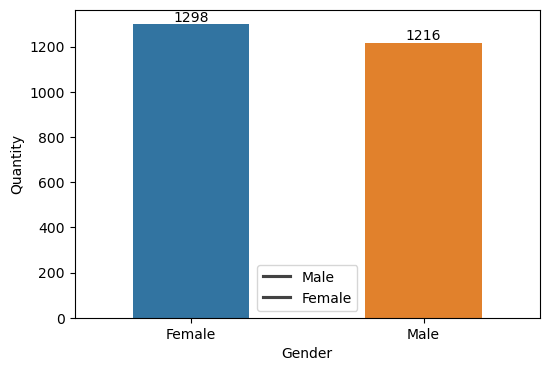

In [49]:
plt.figure(figsize=(6,4))
ax = sns.barplot(x='Gender',y='Quantity',data=df_q ,palette=sns.color_palette("tab10"),width=.5)
plt.legend(['Male','Female'])
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

In [50]:
df_totla = df.groupby(['Gender'],as_index=False)['Total Amount'].sum()
df_totla

,Gender,Total Amount
0,Female,232840
1,Male,223160


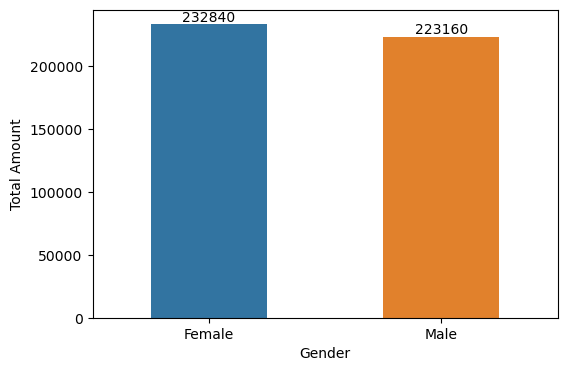

In [51]:
plt.figure(figsize=(6,4))
ax = sns.barplot(x='Gender',y='Total Amount',data=df_totla,palette=sns.color_palette("tab10"),width=.5)
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

In [52]:
df_male_female =  df.groupby(['Gender','month'],as_index=False).size().sort_values(by='month',ascending=False)
df_male_female

,Gender,month,size
23,Male,12,36
11,Female,12,55
10,Female,11,39
22,Male,11,39
21,Male,10,53
9,Female,10,43
8,Female,9,35
20,Male,9,30
7,Female,8,50
19,Male,8,44


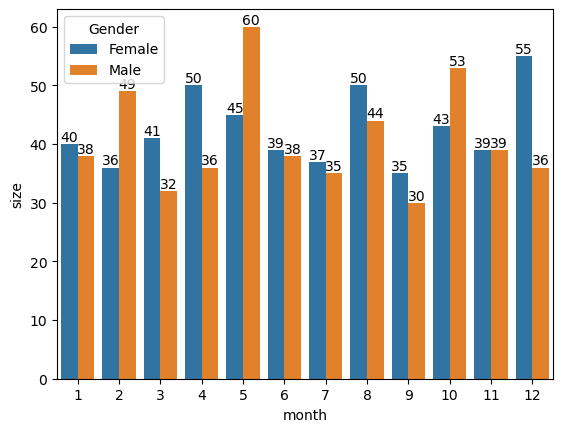

In [53]:
ax = sns.barplot(x='month',y='size',hue='Gender',data=df_male_female,palette=sns.color_palette("tab10"))
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

In [54]:
df

,index,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,month
0,0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11
1,1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2
2,2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1
3,3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5
4,4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5
...,...,...,...,...,...,...,...,...,...,...,...
995,995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,5
996,996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,11
997,997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,10
998,998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,12


# 	Age	 

In [55]:
df_age = df['Age'].value_counts().sort_values(ascending=False).head()
df_age

Age
43    31
64    31
57    30
51    30
34    28
Name: count, dtype: int64

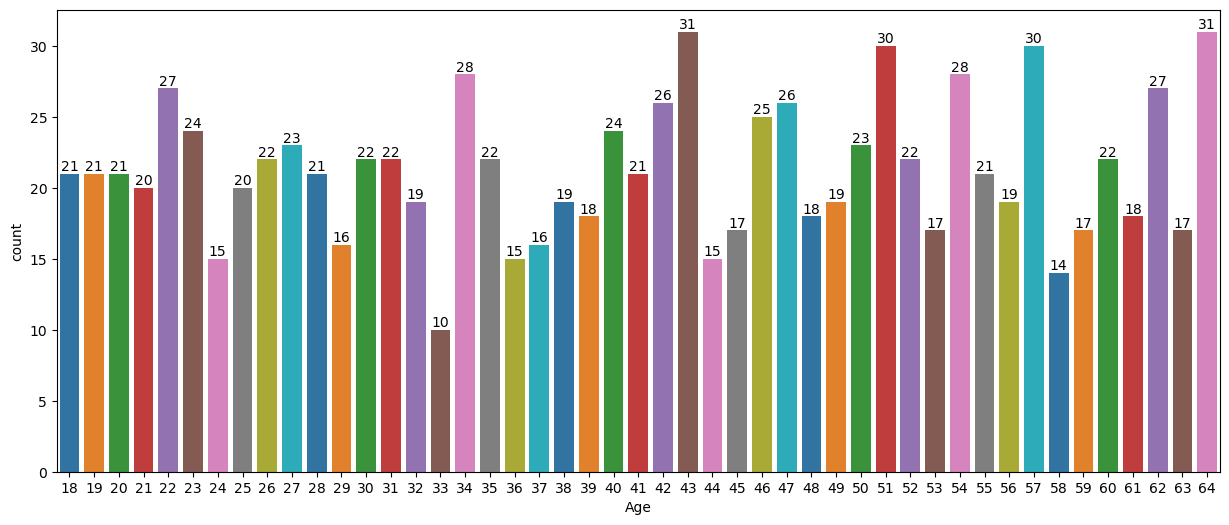

In [56]:
plt.figure(figsize=(15,6))
ax = sns.countplot(x='Age',data=df,palette=sns.color_palette())
for bars in ax.containers: 
    ax.bar_label(bars)
plt.show()

In [57]:
df_filtered = df[df['Age'] == 43]
df_filtered.groupby(['Gender'],as_index=False).size()

,Gender,size
0,Female,19
1,Male,12


In [58]:
df_filtered = df[df['Age'] == 64]
df_filtered.groupby(['Gender'],as_index=False).size()

,Gender,size
0,Female,19
1,Male,12


In [59]:
df_filtered = df[df['Age'] == 37]
df_filtered.groupby(['Gender'],as_index=False).size()

,Gender,size
0,Female,8
1,Male,8


In [60]:
df_age_to = df.groupby(['Age', 'Gender'])['Total Amount'].mean().reset_index()
df_age_to 


,Age,Gender,Total Amount
0,18,Female,610.769231
1,18,Male,409.375000
2,19,Female,666.818182
3,19,Male,753.500000
4,20,Female,431.250000
...,...,...,...
89,62,Male,316.250000
90,63,Female,200.833333
91,63,Male,731.363636
92,64,Female,332.894737


Text(0.5, 1.0, 'Relationship between Age and Total Amount by Gender')

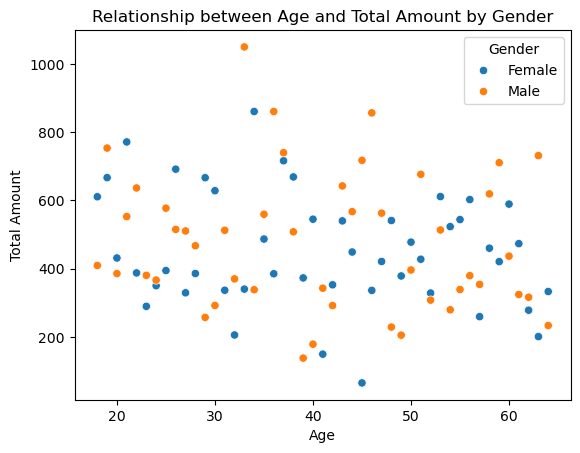

In [61]:
sns.scatterplot(x='Age', y='Total Amount', hue='Gender', data=df_age_to, palette='tab10')
plt.xlabel('Age')
plt.ylabel('Total Amount')
plt.title('Relationship between Age and Total Amount by Gender')

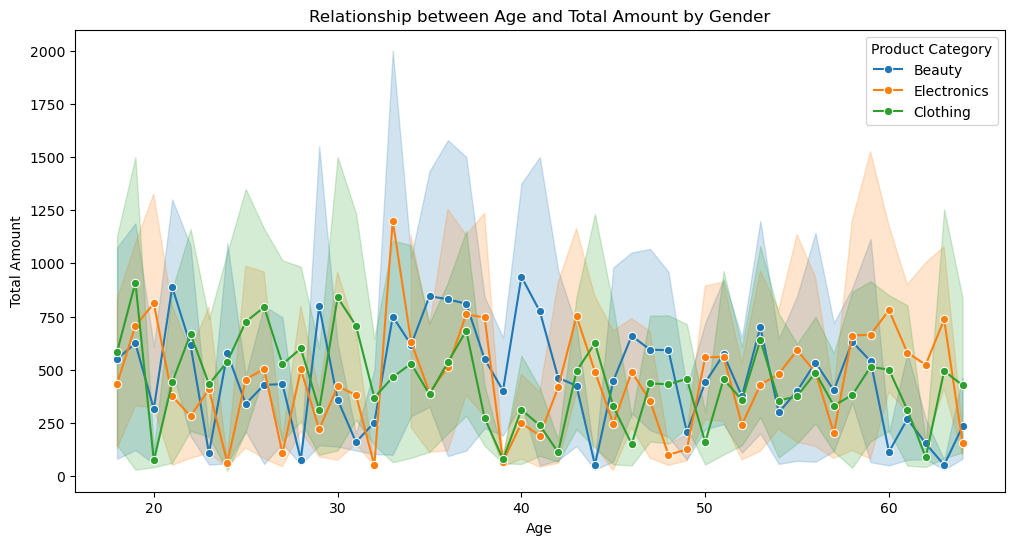

In [62]:
df_sorted = df.sort_values(by=['Age', 'Gender'])
plt.figure(figsize=(12,6))
sns.lineplot(x='Age', y='Total Amount', hue='Product Category', data=df_sorted, palette='tab10', marker='o')
plt.xlabel('Age')
plt.ylabel('Total Amount')
plt.title('Relationship between Age and Total Amount by Gender')
plt.show()


In [63]:
df_age_Product = df.groupby(['Product Category'],as_index=False)['Age'].mean()
df_age_Product

,Product Category,Age
0,Beauty,40.371336
1,Clothing,41.948718
2,Electronics,41.736842


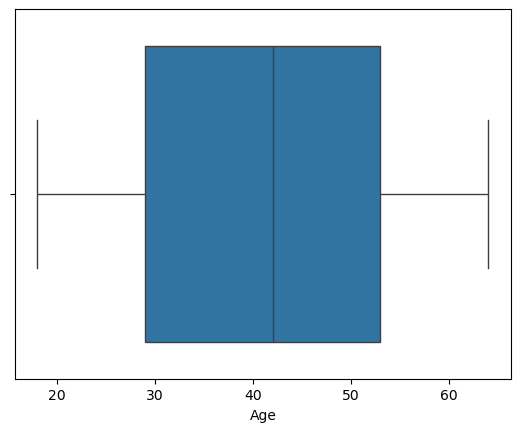

In [64]:
sns.boxplot(data=df,x='Age')
plt.show()

In [65]:
Q1 = df['Age'].quantile(.25)
Q3 = df['Age'].quantile(.75)
IQR = Q3 - Q1 
up = Q3 + 1.5 * (IQR)
lw = Q1 - 1.5 * (IQR)

In [66]:
print(IQR)
print(f'the Upper Bound is {up} ')
print(f'the lower Bound is {lw} ')

24.0
the Upper Bound is 89.0 
the lower Bound is -7.0 


In [67]:
df

,index,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,month
0,0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11
1,1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2
2,2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1
3,3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5
4,4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5
...,...,...,...,...,...,...,...,...,...,...,...
995,995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,5
996,996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,11
997,997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,10
998,998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,12


# Product Category

In [68]:
Category =  df['Product Category'].value_counts()
Category

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

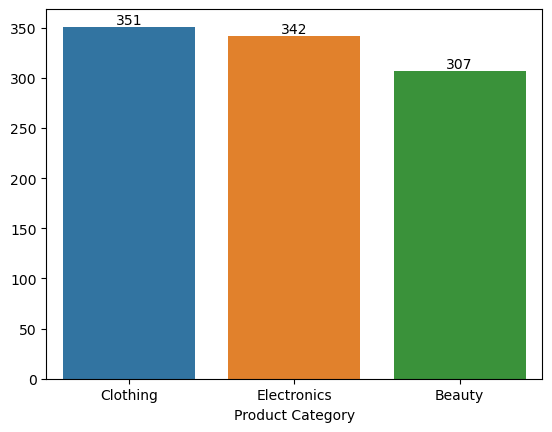

In [69]:
ax  = sns.barplot(x=Category.index,y=Category.values,palette=sns.color_palette("tab10"))
for bars in ax.containers: 
    ax.bar_label(bars)
plt.show()

In [70]:
df_top_Cat = df.groupby(['Product Category','Gender'],as_index=False)['Quantity'].count().sort_values(by='Quantity',ascending=False)
df_top_Cat

,Product Category,Gender,Quantity
3,Clothing,Male,177
2,Clothing,Female,174
5,Electronics,Male,172
4,Electronics,Female,170
0,Beauty,Female,166
1,Beauty,Male,141


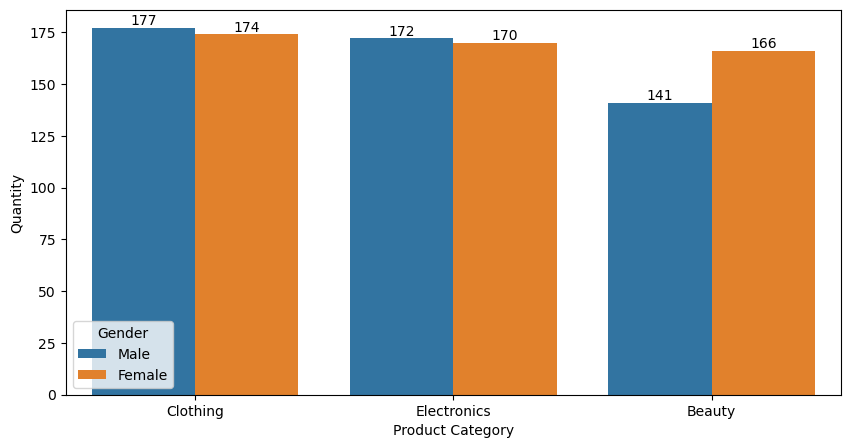

In [71]:
plt.figure(figsize=(10,5))
ax = sns.barplot(x='Product Category',y='Quantity',hue='Gender',data=df_top_Cat,palette=sns.color_palette("tab10"))
for bars in ax.containers: 
    ax.bar_label(bars)
plt.show()

In [72]:
df_pri = df.groupby(['Product Category'],as_index=False)['Price per Unit'].sum()
df_pri

,Product Category,Price per Unit
0,Beauty,56505
1,Clothing,61175
2,Electronics,62210


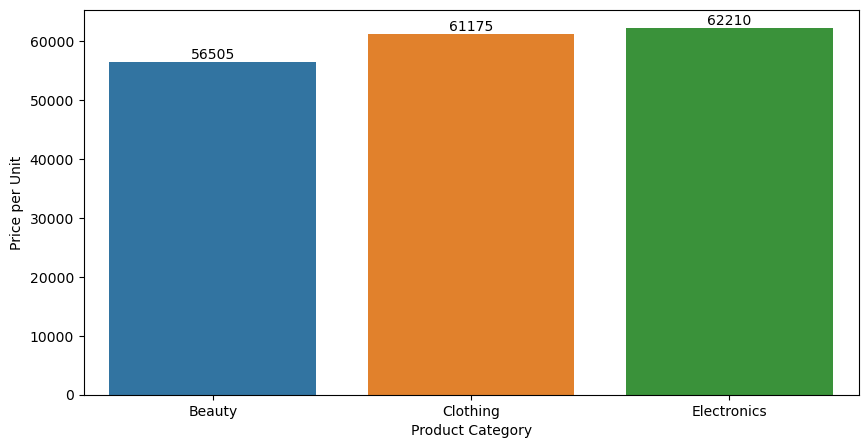

In [73]:
plt.figure(figsize=(10,5))
ax = sns.barplot(x='Product Category',y='Price per Unit',data=df_pri,palette=sns.color_palette("tab10"))
for bars in ax.containers: 
    ax.bar_label(bars)
plt.show()

In [74]:
df_tot = df.groupby(['Product Category'],as_index=False)['Total Amount'].sum()
df_tot

,Product Category,Total Amount
0,Beauty,143515
1,Clothing,155580
2,Electronics,156905


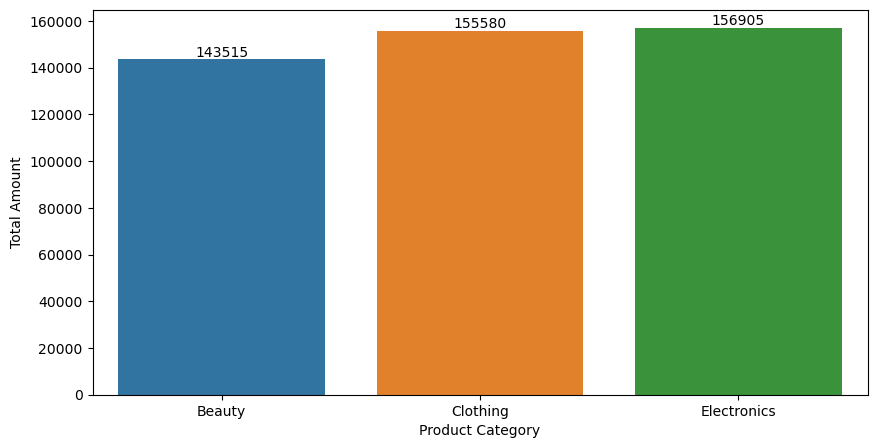

In [75]:
plt.figure(figsize=(10,5))
ax = sns.barplot(x='Product Category',y='Total Amount',data=df_tot,palette=sns.color_palette("tab10"))
for bars in ax.containers: 
    ax.bar_label(bars)
plt.show()

In [76]:
df

,index,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,month
0,0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11
1,1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2
2,2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1
3,3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5
4,4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5
...,...,...,...,...,...,...,...,...,...,...,...
995,995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,5
996,996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,11
997,997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,10
998,998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,12


# Quantity

In [77]:
df['Quantity'].value_counts()

Quantity
4    263
1    253
2    243
3    241
Name: count, dtype: int64

In [78]:
filter_qun = df[df['Quantity']==4]
filter_qun.groupby(['Product Category'],as_index=False).size()

,Product Category,size
0,Beauty,73
1,Clothing,97
2,Electronics,93


In [79]:
df_q_p = df.groupby(['Quantity'],as_index=False)['Price per Unit'].sum()
df_q_p

,Quantity,Price per Unit
0,1,44805
1,2,40525
2,3,48095
3,4,46465


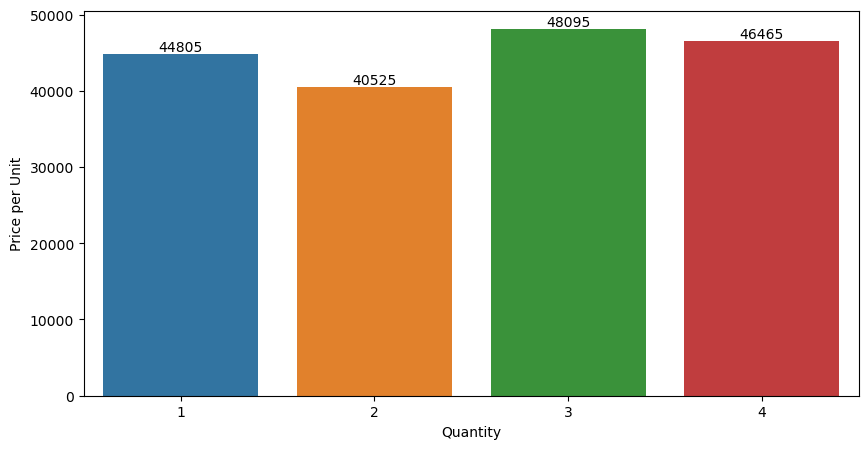

In [80]:
plt.figure(figsize=(10,5))
ax = sns.barplot(x='Quantity',y='Price per Unit',data=df_q_p,palette=sns.color_palette("tab10"))
for bars in ax.containers: 
    ax.bar_label(bars)
plt.show()

In [81]:
df_q_p = df.groupby(['Quantity'],as_index=False)['month'].size()
df_q_p

,Quantity,size
0,1,253
1,2,243
2,3,241
3,4,263


# How do customers adapt their shopping habits during seasonal trends?

In [82]:
df['season'] = df['month'].apply(lambda x:'Winter' if x in [12,1,2] else ('Spring' if x in [3,4,5] else ('summer' if x in [6,7,8]else'Fall')))

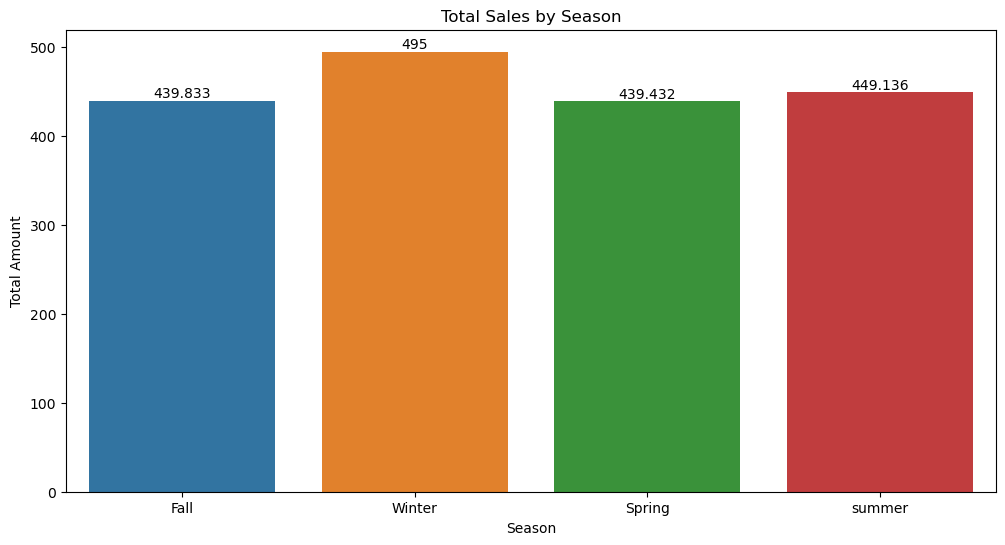

In [83]:
plt.figure(figsize=(12,6))
ax = sns.barplot(x='season', y='Total Amount', data=df,ci=None, palette='tab10')
for bars in ax.containers: 
    ax.bar_label(bars)
plt.title('Total Sales by Season')
plt.xlabel('Season')
plt.ylabel('Total Amount')
plt.show()

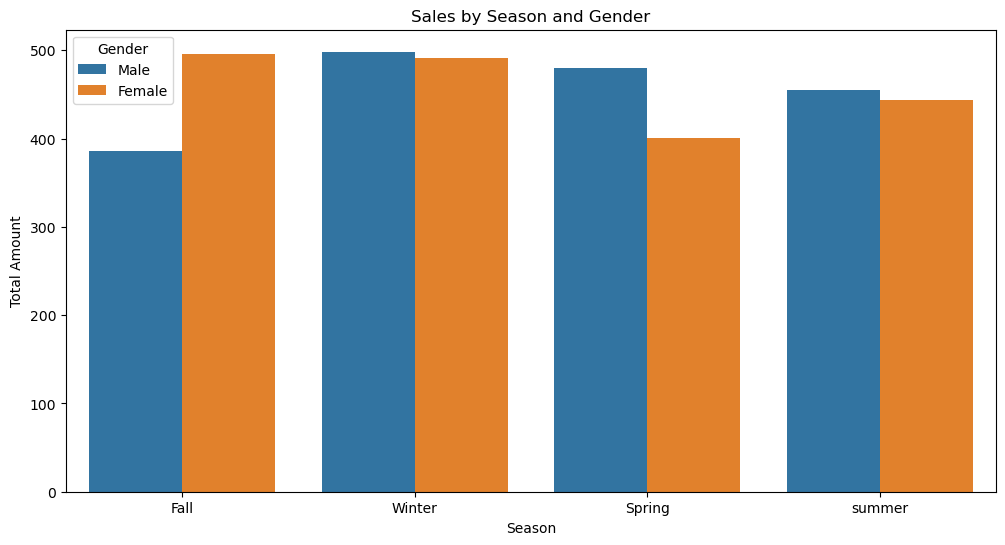

In [84]:
plt.figure(figsize=(12,6))
sns.barplot(x='season', y='Total Amount', hue='Gender',ci=None, data=df, palette='tab10')
plt.title('Sales by Season and Gender')
plt.xlabel('Season')
plt.ylabel('Total Amount')
plt.show()

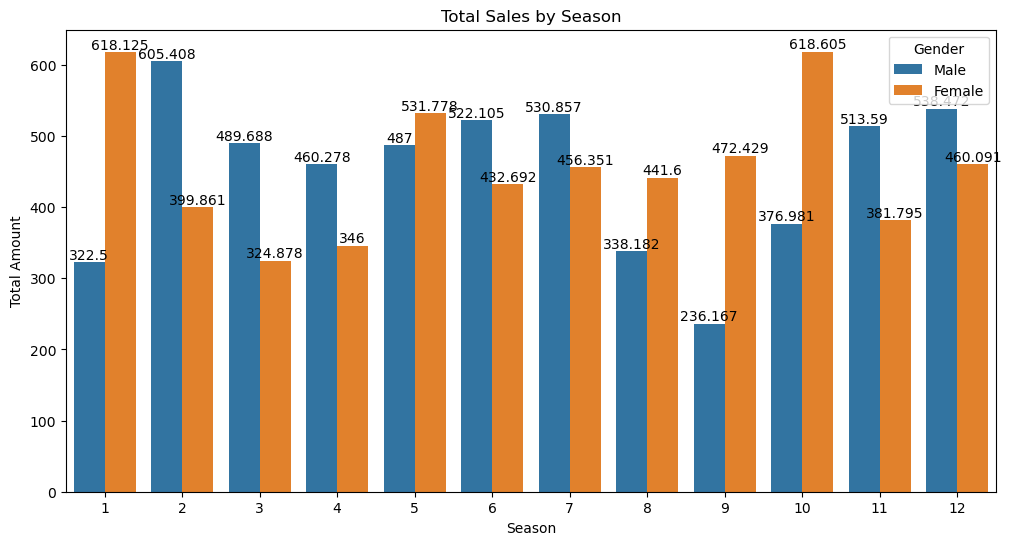

In [85]:
plt.figure(figsize=(12,6))
ax = sns.barplot(x='month', y='Total Amount',hue='Gender', data=df,ci=None, palette='tab10')
for bars in ax.containers: 
    ax.bar_label(bars)
plt.title('Total Sales by Season')
plt.xlabel('Season')
plt.ylabel('Total Amount')
plt.show()

In [86]:
df['Holiday'] = df['Date'].apply(lambda x : 1 if x in pd.to_datetime(['2023-04-21', '2023-07-01']) else 0)

In [87]:
df['Holiday'].sum()

np.int64(6)

In [88]:
Holiday_Sales = df.groupby(['Holiday'],as_index=False)['Total Amount'].sum()
Holiday_Sales

,Holiday,Total Amount
0,0,454080
1,1,1920


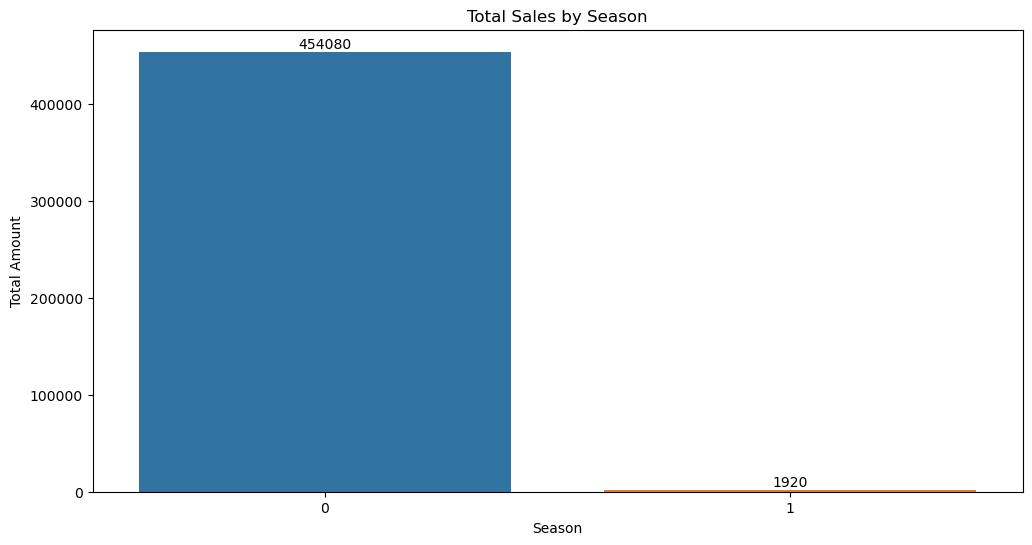

In [89]:
plt.figure(figsize=(12,6))
ax = sns.barplot(x='Holiday', y='Total Amount', data=Holiday_Sales,ci=None, palette='tab10')
for bars in ax.containers: 
    ax.bar_label(bars)
plt.title('Total Sales by Season')
plt.xlabel('Season')
plt.ylabel('Total Amount')
plt.show()

In [90]:
df

,index,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,month,season,Holiday
0,0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11,Fall,0
1,1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2,Winter,0
2,2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1,Winter,0
3,3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5,Spring,0
4,4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5,Spring,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,5,Spring,0
996,996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,11,Fall,0
997,997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,10,Fall,0
998,998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,12,Winter,0


In [91]:
df['Price per Unit'].value_counts()

Price per Unit
50     211
25     210
500    199
300    197
30     183
Name: count, dtype: int64

In [92]:
df.groupby(['Price per Unit'],as_index=False)['Quantity'].sum()

,Price per Unit,Quantity
0,25,522
1,30,445
2,50,534
3,300,518
4,500,495


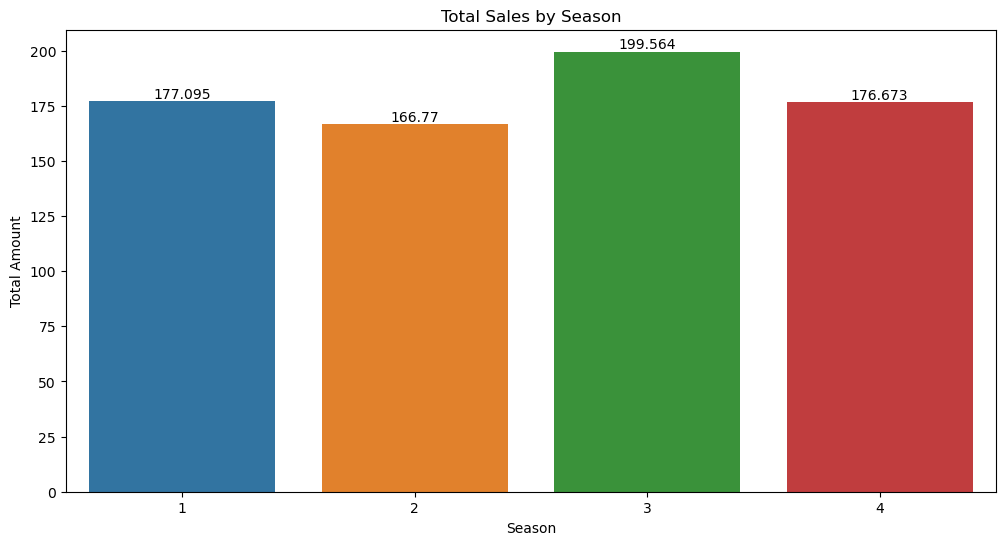

In [93]:
plt.figure(figsize=(12,6))
ax = sns.barplot(x='Quantity', y='Price per Unit', data=df,ci=None, palette='tab10')
for bars in ax.containers: 
    ax.bar_label(bars)
plt.title('Total Sales by Season')
plt.xlabel('Season')
plt.ylabel('Total Amount')
plt.show()

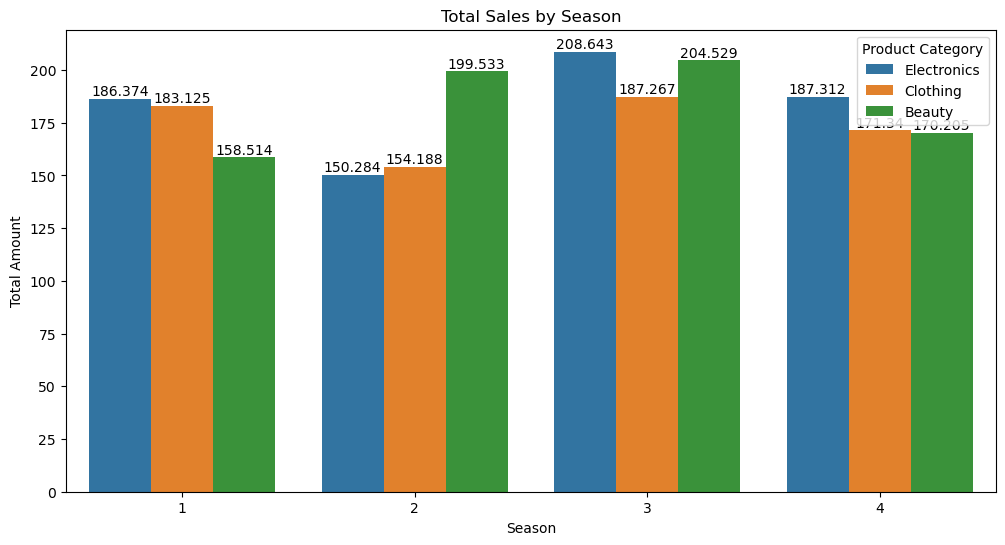

In [94]:
plt.figure(figsize=(12,6))
ax = sns.barplot(x='Quantity', y='Price per Unit',hue='Product Category' , data=df,ci=None, palette='tab10')
for bars in ax.containers: 
    ax.bar_label(bars)
plt.title('Total Sales by Season')
plt.xlabel('Season')
plt.ylabel('Total Amount')
plt.show()

In [95]:
df.groupby(['month','Price per Unit'],as_index=False)['Quantity'].count()

,month,Price per Unit,Quantity
0,1,25,17
1,1,30,19
2,1,50,11
3,1,300,12
4,1,500,19
5,2,25,23
6,2,30,11
7,2,50,15
8,2,300,17
9,2,500,19


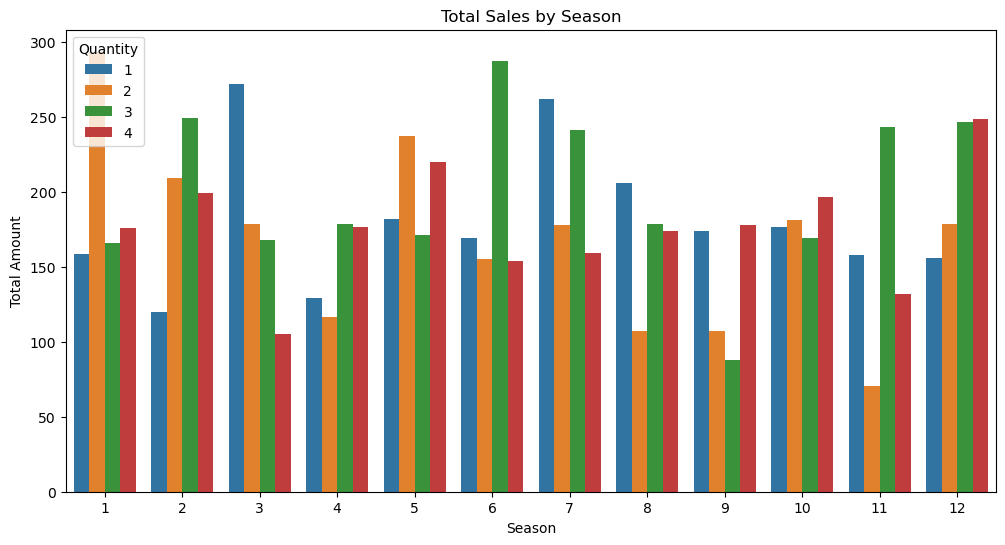

In [96]:
plt.figure(figsize=(12,6))
sns.barplot(x='month', y='Price per Unit',hue='Quantity' , data=df,ci=None, palette='tab10')
plt.title('Total Sales by Season')
plt.xlabel('Season')
plt.ylabel('Total Amount')
plt.show()

In [97]:
df

,index,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,month,season,Holiday
0,0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11,Fall,0
1,1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2,Winter,0
2,2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1,Winter,0
3,3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5,Spring,0
4,4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5,Spring,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,5,Spring,0
996,996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,11,Fall,0
997,997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,10,Fall,0
998,998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,12,Winter,0


In [98]:
df.groupby(['Product Category','Price per Unit','season'],as_index=False).size()

,Product Category,Price per Unit,season,size
0,Beauty,25,Fall,21
1,Beauty,25,Spring,15
2,Beauty,25,Winter,18
3,Beauty,25,summer,9
4,Beauty,30,Fall,14
5,Beauty,30,Spring,12
6,Beauty,30,Winter,13
7,Beauty,30,summer,17
8,Beauty,50,Fall,16
9,Beauty,50,Spring,18


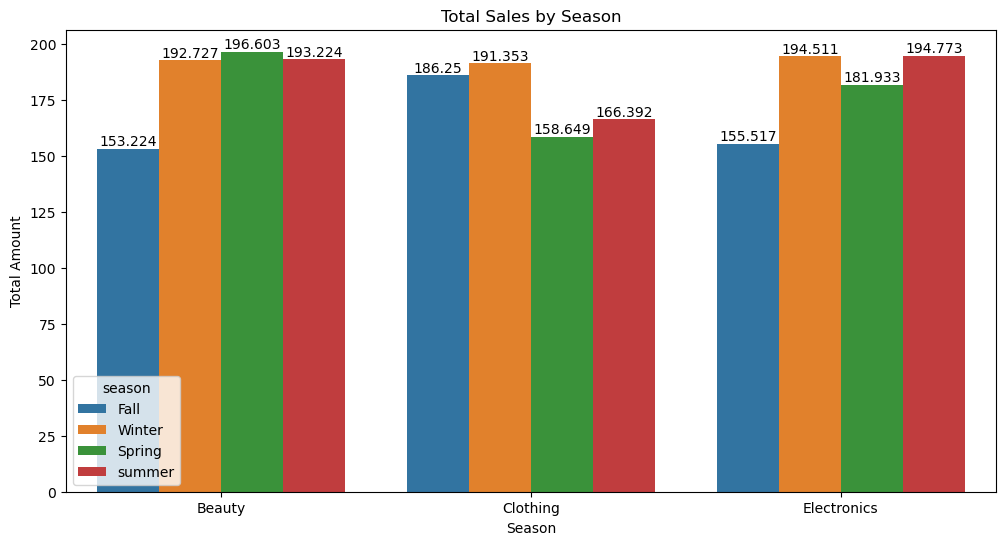

In [99]:
plt.figure(figsize=(12,6))
ax = sns.barplot(x='Product Category', y='Price per Unit',hue='season' , data=df,ci=None, palette='tab10')
for bars in ax.containers: 
    ax.bar_label(bars)
plt.title('Total Sales by Season')
plt.xlabel('Season')
plt.ylabel('Total Amount')
plt.show()

In [100]:
df

,index,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,month,season,Holiday
0,0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11,Fall,0
1,1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2,Winter,0
2,2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1,Winter,0
3,3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5,Spring,0
4,4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5,Spring,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,5,Spring,0
996,996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,11,Fall,0
997,997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,10,Fall,0
998,998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,12,Winter,0


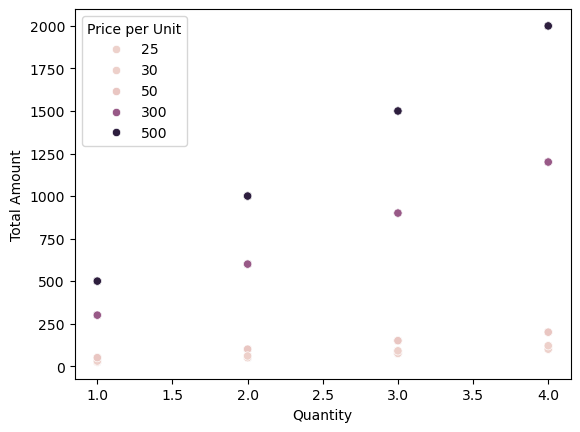

In [101]:
sns.scatterplot(x='Quantity',y='Total Amount',hue='Price per Unit',data=df)
plt.show()

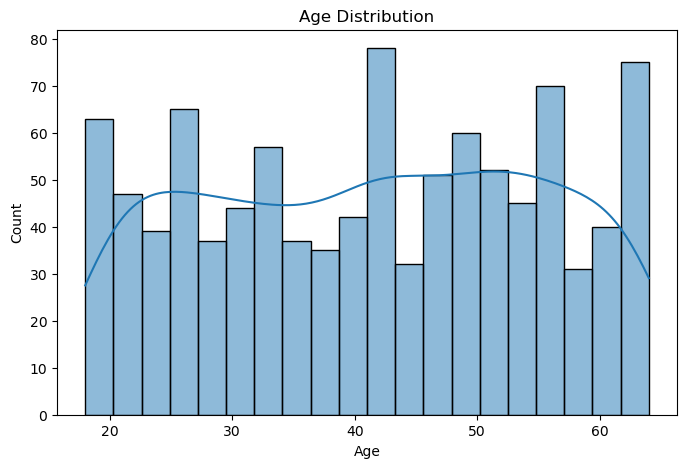

In [103]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

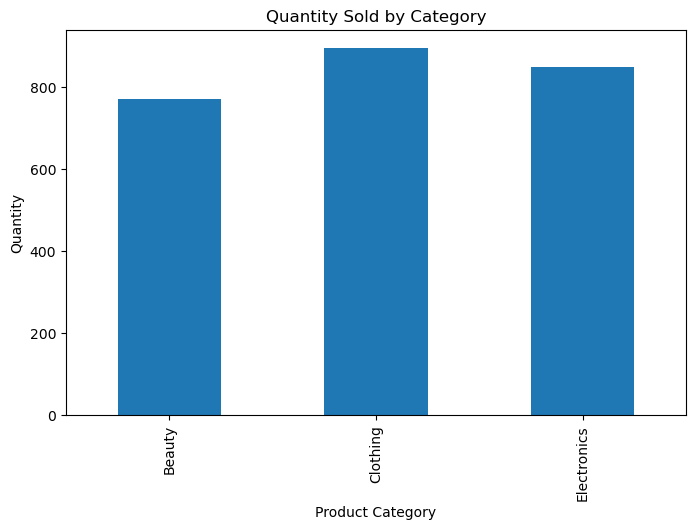

In [104]:
category_qty = df.groupby('Product Category')['Quantity'].sum()

plt.figure(figsize=(8,5))
category_qty.plot(kind='bar')
plt.title('Quantity Sold by Category')
plt.ylabel('Quantity')
plt.show()

# Conclusion

This project successfully analyzed retail sales data to identify key business trends, customer purchasing behavior, and product performance. The dataset was cleaned and prepared using Python and SQL techniques, ensuring data quality and consistency before analysis.

Through exploratory data analysis and visualization, several valuable insights were discovered. Sales performance varied across different product categories, customer demographics, and time periods. Product category analysis revealed the most profitable segments, while gender and age-based analysis provided a better understanding of customer preferences. Monthly and seasonal sales trends highlighted periods of high business activity and opportunities for targeted marketing strategies.

SQL queries were used to perform data extraction, aggregation, and reporting, while Python libraries such as Pandas, Matplotlib, and Seaborn were utilized for data processing and visualization. The combination of these tools enabled efficient analysis and clear presentation of business insights.

The findings from this project can help retail businesses make data-driven decisions regarding inventory management, marketing campaigns, customer targeting, and sales optimization. Overall, the project demonstrates the practical application of data analytics techniques in transforming raw retail data into meaningful business intelligence.


## Future Scope

- Develop an interactive dashboard using Power BI or Tableau.
- Implement sales forecasting using machine learning models.
- Perform customer segmentation for targeted marketing.
- Build an automated reporting system for real-time business monitoring.
- Integrate multiple data sources to improve business insights.